In [1]:
# ============================================================
# CELL 1 — Imports and rebuild both pipelines from saved data
# ============================================================
# We reload the saved X/y CSVs and the trained models so this
# notebook works standalone, without re-running training.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Load saved models and scalers ---
model_early  = joblib.load('failsafe_model_early.pkl')
scaler_early = joblib.load('failsafe_scaler_early.pkl')

model_mid  = joblib.load('failsafe_model_mid.pkl')
scaler_mid = joblib.load('failsafe_scaler_mid.pkl')

# --- Load saved feature lists ---
with open('feature_names_early.json') as f:
    features_early = json.load(f)
with open('feature_names_mid.json') as f:
    features_mid = json.load(f)

# --- Reload the X/y data and recreate the SAME train/test split ---
# (random_state=42 guarantees this matches the split used during training)
X_early = pd.read_csv("X_early.csv")
y_early = pd.read_csv("y_early.csv").squeeze()
X_mid   = pd.read_csv("X_mid.csv")
y_mid   = pd.read_csv("y_mid.csv").squeeze()

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_early, y_early, test_size=0.20, random_state=42, stratify=y_early)
X_test_e_scaled = scaler_early.transform(X_test_e)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mid, y_mid, test_size=0.20, random_state=42, stratify=y_mid)
X_test_m_scaled = scaler_mid.transform(X_test_m)

print("Pipelines rebuilt for both models.")
print(f"Early test set : {X_test_e_scaled.shape}")
print(f"Mid test set   : {X_test_m_scaled.shape}")

C:\Users\MANVITHA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pipelines rebuilt for both models.
Early test set : (79, 42)
Mid test set   : (79, 43)


Early model SHAP values shape: (79, 42)
Base risk (average student): 0.0880


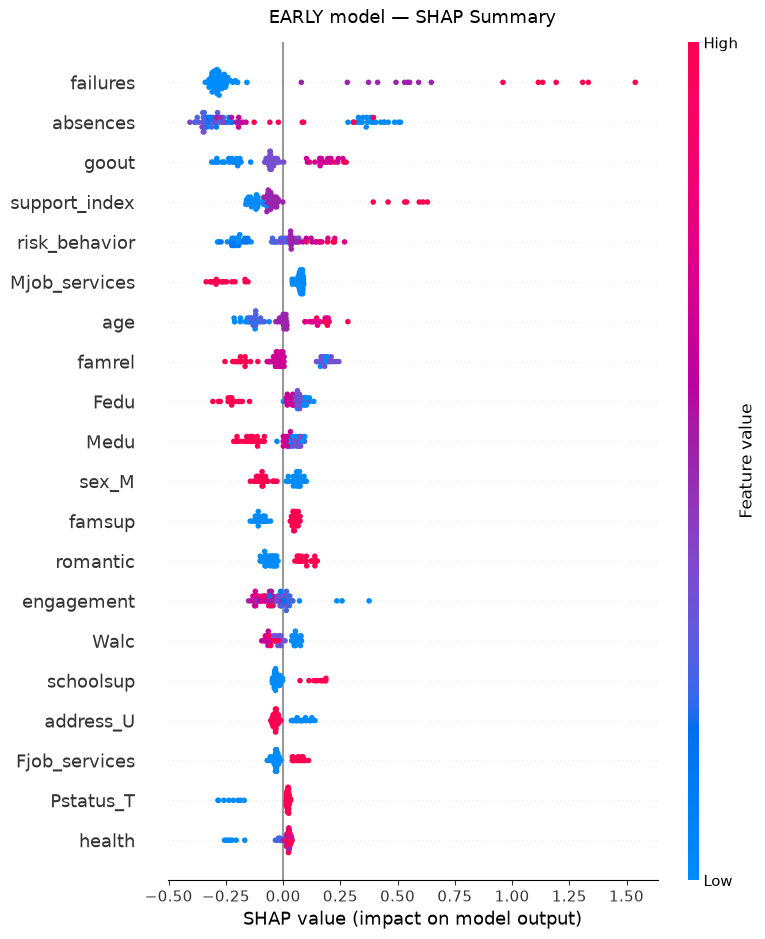

Saved: shap_summary_early.png


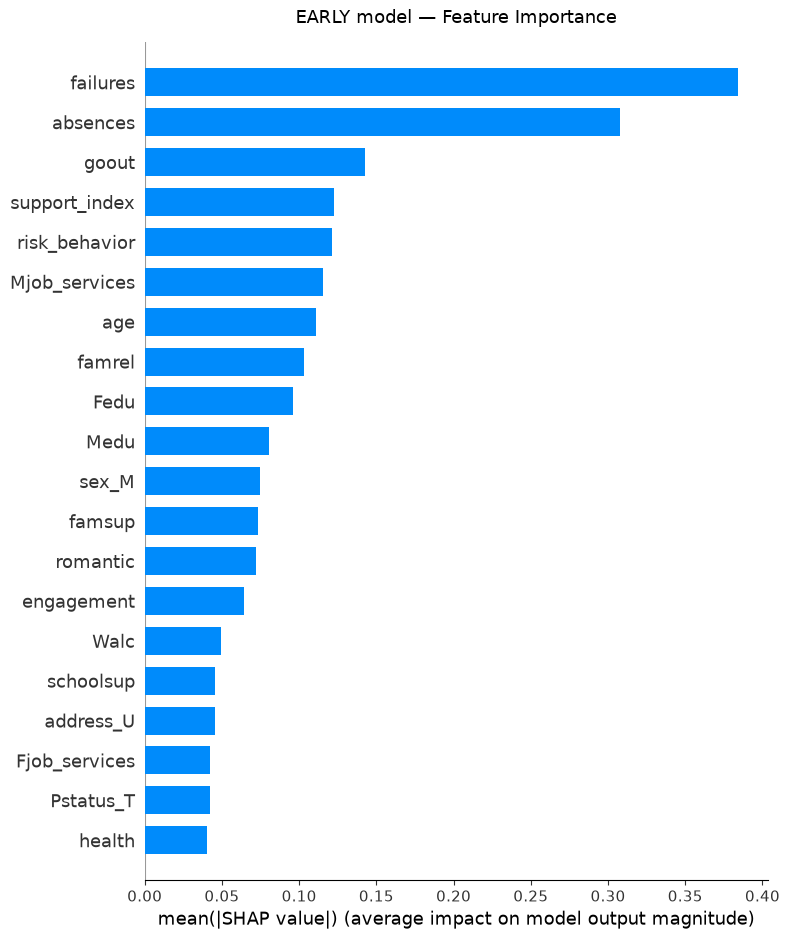

Saved: shap_importance_early.png


In [2]:
# ============================================================
# CELL 2 — SHAP analysis for the EARLY model
# ============================================================

explainer_early = shap.TreeExplainer(model_early)
shap_values_early = explainer_early.shap_values(X_test_e_scaled)

print("Early model SHAP values shape:", shap_values_early.shape)
print(f"Base risk (average student): {explainer_early.expected_value:.4f}")

# Beeswarm summary — which features matter most, and in which direction
shap.summary_plot(shap_values_early, X_test_e_scaled,
                   feature_names=features_early, show=False)
plt.title("EARLY model — SHAP Summary", fontsize=13, pad=14)
plt.tight_layout()
plt.savefig("shap_summary_early.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_early.png")

# Bar chart — overall importance ranking
shap.summary_plot(shap_values_early, X_test_e_scaled,
                   feature_names=features_early, plot_type="bar", show=False)
plt.title("EARLY model — Feature Importance", fontsize=13, pad=14)
plt.tight_layout()
plt.savefig("shap_importance_early.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_importance_early.png")

Mid-semester model SHAP values shape: (79, 43)
Base risk (average student): 0.0073


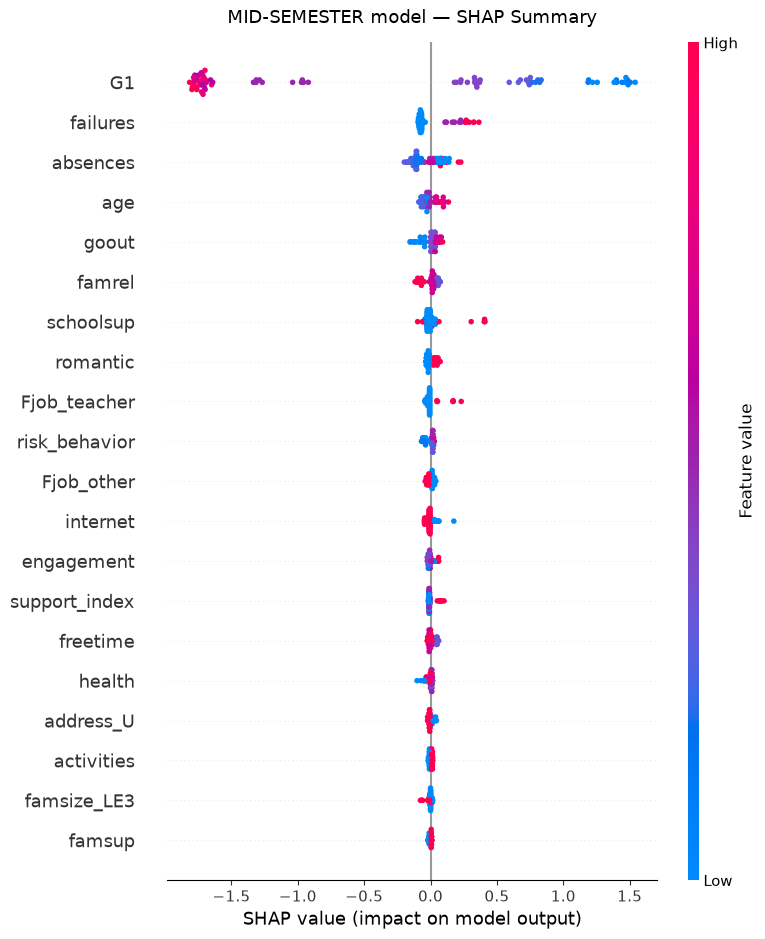

Saved: shap_summary_mid.png


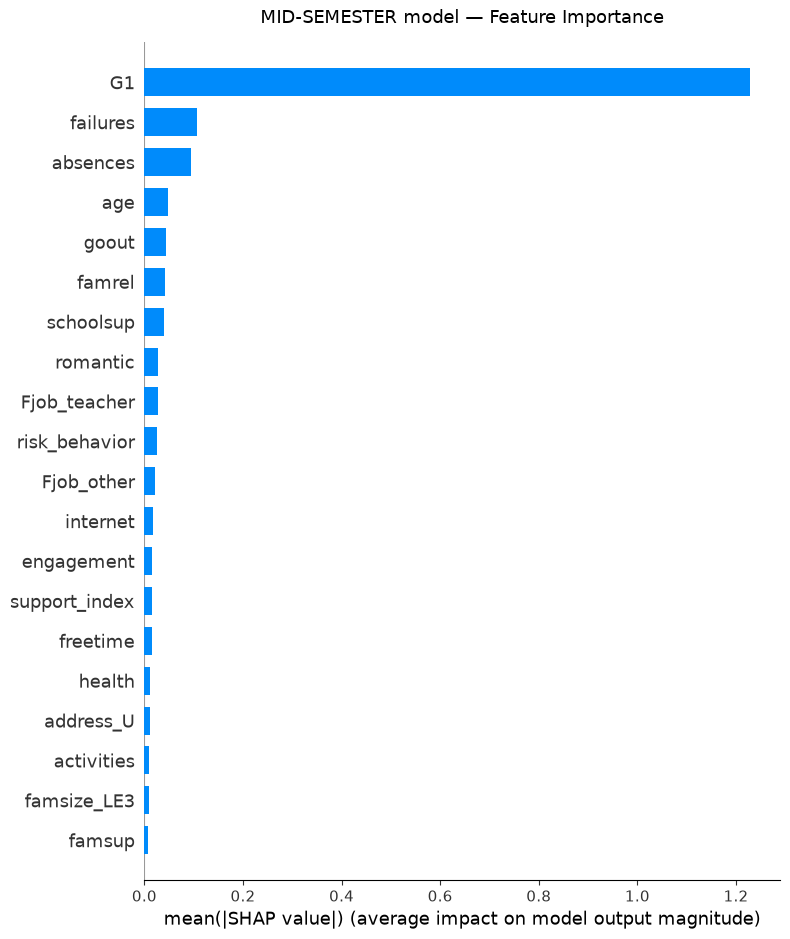

Saved: shap_importance_mid.png


In [3]:
# ============================================================
# CELL 3 — SHAP analysis for the MID-SEMESTER model
# ============================================================

explainer_mid = shap.TreeExplainer(model_mid)
shap_values_mid = explainer_mid.shap_values(X_test_m_scaled)

print("Mid-semester model SHAP values shape:", shap_values_mid.shape)
print(f"Base risk (average student): {explainer_mid.expected_value:.4f}")

shap.summary_plot(shap_values_mid, X_test_m_scaled,
                   feature_names=features_mid, show=False)
plt.title("MID-SEMESTER model — SHAP Summary", fontsize=13, pad=14)
plt.tight_layout()
plt.savefig("shap_summary_mid.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_mid.png")

shap.summary_plot(shap_values_mid, X_test_m_scaled,
                   feature_names=features_mid, plot_type="bar", show=False)
plt.title("MID-SEMESTER model — Feature Importance", fontsize=13, pad=14)
plt.tight_layout()
plt.savefig("shap_importance_mid.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_importance_mid.png")

In [4]:
# ============================================================
# CELL 4 — Quantify G1's share of total model "attention"
# ============================================================
# This directly answers: is the mid-semester model basically
# just reading G1, or are the other 42 features still pulling
# real weight alongside it?

mean_abs_shap_mid = np.abs(shap_values_mid).mean(axis=0)
total_importance = mean_abs_shap_mid.sum()

g1_idx = features_mid.index('G1')
g1_importance = mean_abs_shap_mid[g1_idx]
g1_share = (g1_importance / total_importance) * 100

print(f"G1's mean |SHAP| value        : {g1_importance:.4f}")
print(f"Total importance (all features): {total_importance:.4f}")
print(f"G1's share of total model attention: {g1_share:.1f}%")
print(f"Remaining {100-g1_share:.1f}% spread across the other {len(features_mid)-1} features")

# Show the top 10 features ranked, so you can see exactly where
# G1 sits relative to everything else
importance_df = pd.DataFrame({
    'feature': features_mid,
    'mean_abs_shap': mean_abs_shap_mid
}).sort_values('mean_abs_shap', ascending=False).head(10)

print("\nTop 10 features by importance:")
print(importance_df.to_string(index=False))

if g1_share > 60:
    print("\nInterpretation: G1 dominates the model. Other features contribute,")
    print("but G1 is doing most of the predictive work.")
elif g1_share > 30:
    print("\nInterpretation: G1 is the single strongest feature, but the model")
    print("genuinely combines it with multiple behavioural signals.")
else:
    print("\nInterpretation: G1 is influential but not dominant — the model is")
    print("using a balanced mix of grade and behavioural information.")

G1's mean |SHAP| value        : 1.2278
Total importance (all features): 1.8995
G1's share of total model attention: 64.6%
Remaining 35.4% spread across the other 42 features

Top 10 features by importance:
      feature  mean_abs_shap
           G1       1.227834
     failures       0.107676
     absences       0.094089
          age       0.047949
        goout       0.042973
       famrel       0.041030
    schoolsup       0.039482
     romantic       0.028449
 Fjob_teacher       0.027417
risk_behavior       0.025274

Interpretation: G1 dominates the model. Other features contribute,
but G1 is doing most of the predictive work.


Early model — riskiest student: index 67, risk 89.1%
Mid model   — riskiest student: index 67, risk 88.8%


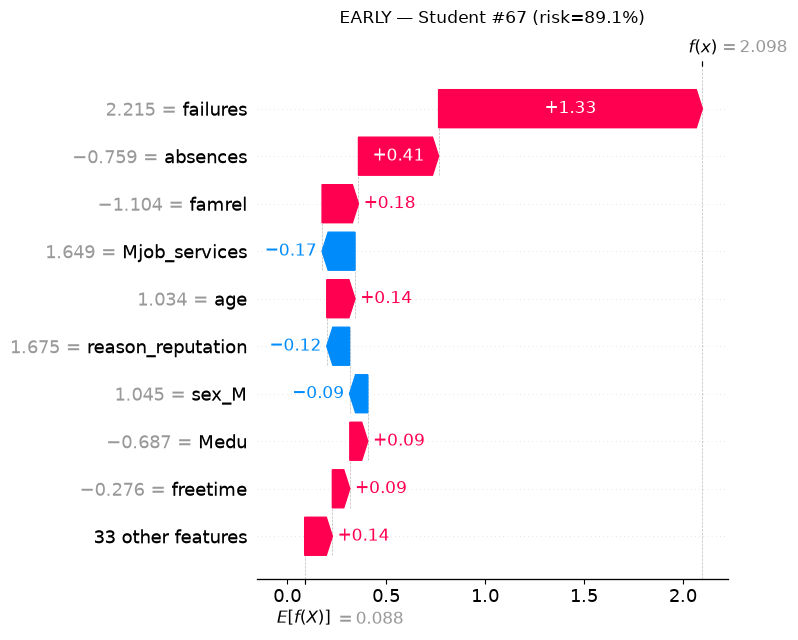

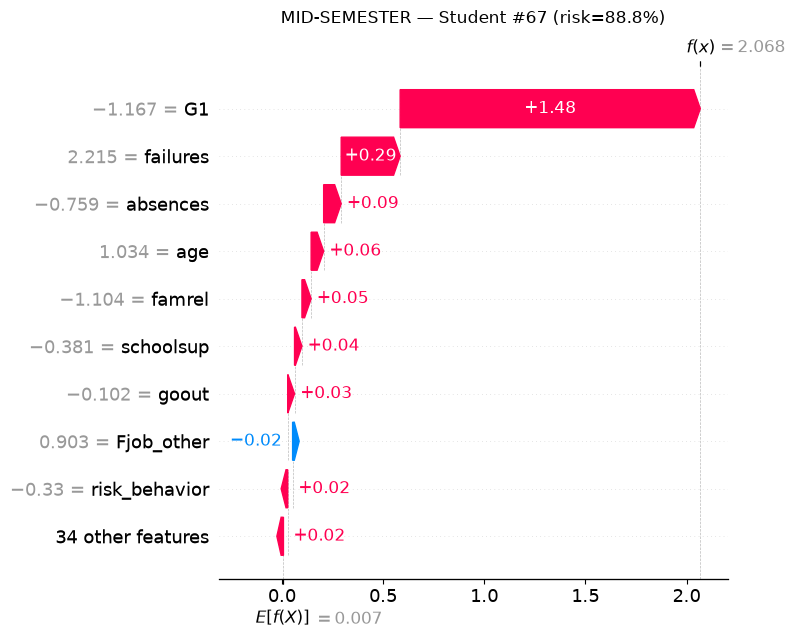

Saved: shap_waterfall_early.png, shap_waterfall_mid.png


In [5]:
# ============================================================
# CELL 5 — Explain one at-risk student under both checkpoints
# ============================================================
# Picks the same logical "most at-risk" student under each
# model's own test set (note: these may be different students,
# since the splits were built from different feature sets).

y_prob_early = model_early.predict_proba(X_test_e_scaled)[:, 1]
y_prob_mid   = model_mid.predict_proba(X_test_m_scaled)[:, 1]

idx_early = np.argmax(y_prob_early)
idx_mid   = np.argmax(y_prob_mid)

print(f"Early model — riskiest student: index {idx_early}, risk {y_prob_early[idx_early]:.1%}")
print(f"Mid model   — riskiest student: index {idx_mid}, risk {y_prob_mid[idx_mid]:.1%}")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_early[idx_early],
        base_values=explainer_early.expected_value,
        data=X_test_e_scaled[idx_early],
        feature_names=features_early
    ), show=False
)
plt.title(f"EARLY — Student #{idx_early} (risk={y_prob_early[idx_early]:.1%})", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("shap_waterfall_early.png", dpi=150, bbox_inches='tight')
plt.show()

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_mid[idx_mid],
        base_values=explainer_mid.expected_value,
        data=X_test_m_scaled[idx_mid],
        feature_names=features_mid
    ), show=False
)
plt.title(f"MID-SEMESTER — Student #{idx_mid} (risk={y_prob_mid[idx_mid]:.1%})", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("shap_waterfall_mid.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: shap_waterfall_early.png, shap_waterfall_mid.png")

In [6]:
# ============================================================
# CELL 6 — Export SHAP values for all test students, both models
# ============================================================
# These CSVs are what the FastAPI backend will read later,
# one per checkpoint.

shap_df_early = pd.DataFrame(shap_values_early,
                              columns=[f"shap_{c}" for c in features_early])
shap_df_early.insert(0, 'student_index', range(len(X_test_e)))
shap_df_early.insert(1, 'risk_probability', y_prob_early)
shap_df_early.insert(2, 'actual_at_risk', y_test_e.values)
shap_df_early.to_csv("shap_explanations_early.csv", index=False)

shap_df_mid = pd.DataFrame(shap_values_mid,
                            columns=[f"shap_{c}" for c in features_mid])
shap_df_mid.insert(0, 'student_index', range(len(X_test_m)))
shap_df_mid.insert(1, 'risk_probability', y_prob_mid)
shap_df_mid.insert(2, 'actual_at_risk', y_test_m.values)
shap_df_mid.to_csv("shap_explanations_mid.csv", index=False)

print("Saved: shap_explanations_early.csv  shape:", shap_df_early.shape)
print("Saved: shap_explanations_mid.csv    shape:", shap_df_mid.shape)
print("\nSHAP analysis complete for both checkpoints.")

Saved: shap_explanations_early.csv  shape: (79, 45)
Saved: shap_explanations_mid.csv    shape: (79, 46)

SHAP analysis complete for both checkpoints.


In [7]:
# ============================================================
# CELL 7 — Intervention map, extended with the G1 entry
# ============================================================
# Same map as before, PLUS a new 'G1' entry. This is what was
# missing: when G1 is a student's dominant SHAP driver (which
# we now know happens 64.6% of the time in the mid-semester
# model), the old map had nothing to say about it.

INTERVENTION_MAP = {
    'failures': {
        'label'       : 'History of past failures',
        'intervention': 'Enrol in academic recovery programme. '
                       'Assign a peer mentor who excelled in previously failed subjects. '
                       'Schedule weekly 1-on-1 check-in with subject teacher.',
        'referral'    : 'Academic counsellor'
    },
    'absences': {
        'label'       : 'High absenteeism',
        'intervention': 'Contact parent/guardian to discuss attendance pattern. '
                       'Create an attendance contract with clear targets. '
                       'Investigate root cause: transport, health, or motivation.',
        'referral'    : 'Pastoral care / school counsellor'
    },
    'goout': {
        'label'       : 'Frequent social outings affecting study time',
        'intervention': 'Discuss time management and study-life balance. '
                       'Introduce structured weekly study schedule. '
                       'Consider study group to make study more social.',
        'referral'    : 'Student mentor'
    },
    'studytime': {
        'label'       : 'Insufficient study time',
        'intervention': 'Provide study timetable template. '
                       'Offer supervised study hall sessions after school. '
                       'Connect with library resources and quiet study spaces.',
        'referral'    : 'Academic support centre'
    },
    'schoolsup': {
        'label'       : 'Not receiving school academic support',
        'intervention': 'Immediately enrol student in school support programme. '
                       'Arrange extra tuition sessions in weakest subjects.',
        'referral'    : 'Subject teacher + academic support team'
    },
    'famsup': {
        'label'       : 'Limited family academic support at home',
        'intervention': 'Schedule parent meeting to discuss home study environment. '
                       'Provide take-home study guides for parents. '
                       'Consider after-school homework club.',
        'referral'    : 'Family liaison officer'
    },
    'famrel': {
        'label'       : 'Poor family relationship quality',
        'intervention': 'Refer to school counsellor for wellbeing check. '
                       'Ensure student has a trusted adult contact at school. '
                       'Monitor for signs of stress or emotional distress.',
        'referral'    : 'School counsellor / welfare officer'
    },
    'Dalc': {
        'label'       : 'Daily alcohol consumption concern',
        'intervention': 'Confidential welfare check by school counsellor. '
                       'Referral to substance awareness programme if appropriate.',
        'referral'    : 'School counsellor (confidential)'
    },
    'Walc': {
        'label'       : 'Weekend alcohol consumption concern',
        'intervention': 'Wellbeing conversation with trusted staff member. '
                       'Peer support group or mentoring programme.',
        'referral'    : 'Wellbeing coordinator'
    },
    'health': {
        'label'       : 'Health concerns affecting attendance',
        'intervention': 'Check if student needs reasonable adjustments. '
                       'Liaise with school nurse. '
                       'Create flexible catch-up plan for missed content.',
        'referral'    : 'School nurse / medical officer'
    },
    'romantic': {
        'label'       : 'Romantic relationship impacting focus',
        'intervention': 'Pastoral check-in to ensure wellbeing. '
                       'Reinforce academic goals and long-term aspirations.',
        'referral'    : 'Form tutor / pastoral lead'
    },
    'internet': {
        'label'       : 'No internet access at home',
        'intervention': 'Provide school device loan if available. '
                       'Give access to library computer lab outside hours. '
                       'Provide printed supplementary materials.',
        'referral'    : 'IT / resources coordinator'
    },
    'higher': {
        'label'       : 'Student does not aspire to higher education',
        'intervention': 'Career guidance session to explore vocational pathways. '
                       'Connect with alumni or industry mentors. '
                       'Reframe academic achievement in terms of their goals.',
        'referral'    : 'Careers advisor'
    },
    'Fedu': {
        'label'       : 'Low parental education background',
        'intervention': 'Provide additional structured guidance as family '
                       'may have limited capacity to support academically. '
                       'Increase school-side academic scaffolding.',
        'referral'    : 'Academic support team'
    },
    'Medu': {
        'label'       : 'Low maternal education level',
        'intervention': 'Same as Fedu — increase school-side academic scaffolding. '
                       'Provide clear communication to parents in accessible language.',
        'referral'    : 'Academic support team'
    },
    'freetime': {
        'label'       : 'Excessive free time (low structure)',
        'intervention': 'Encourage enrolment in structured extracurricular activities. '
                       'Introduce goal-setting session with tutor.',
        'referral'    : 'Student activities coordinator'
    },
    'traveltime': {
        'label'       : 'Long travel time to school',
        'intervention': 'Explore transport support options. '
                       'Allow online resource access for missed early sessions. '
                       'Consider flexible start arrangements.',
        'referral'    : 'School administration'
    },

    # --- NEW: covers the G1 case, only present in the mid-semester model ---
    'G1': {
        'label'       : 'Below-expected first-period grade',
        'intervention': 'This is the strongest signal available — treat as the '
                       'primary concern. Schedule a one-on-one review of first-period '
                       'coursework to identify specific weak topics. Arrange targeted '
                       'subject tutoring before the next assessment. Compare with '
                       'attendance/behaviour data on this report to check whether the '
                       'grade reflects a one-off dip or a sustained pattern.',
        'referral'    : 'Subject teacher (priority review)'
    },

    # --- engineered features also need entries, since they can show up too ---
    'support_index': {
        'label'       : 'Low overall support index (school + family + aspiration)',
        'intervention': 'Holistic case review — multiple support layers appear weak '
                       'simultaneously. Coordinate between academic support, family '
                       'liaison, and careers guidance rather than addressing in isolation.',
        'referral'    : 'Pastoral lead (coordinating case

SyntaxError: unterminated string literal (detected at line 142) (2948207281.py, line 142)

In [8]:
# ============================================================
# CELL 7 — Intervention map, extended with the G1 entry
# ============================================================
# Same map as before, PLUS a new 'G1' entry. This is what was
# missing: when G1 is a student's dominant SHAP driver (which
# we now know happens 64.6% of the time in the mid-semester
# model), the old map had nothing to say about it.

INTERVENTION_MAP = {
    'failures': {
        'label'       : 'History of past failures',
        'intervention': 'Enrol in academic recovery programme. '
                       'Assign a peer mentor who excelled in previously failed subjects. '
                       'Schedule weekly 1-on-1 check-in with subject teacher.',
        'referral'    : 'Academic counsellor'
    },
    'absences': {
        'label'       : 'High absenteeism',
        'intervention': 'Contact parent/guardian to discuss attendance pattern. '
                       'Create an attendance contract with clear targets. '
                       'Investigate root cause: transport, health, or motivation.',
        'referral'    : 'Pastoral care / school counsellor'
    },
    'goout': {
        'label'       : 'Frequent social outings affecting study time',
        'intervention': 'Discuss time management and study-life balance. '
                       'Introduce structured weekly study schedule. '
                       'Consider study group to make study more social.',
        'referral'    : 'Student mentor'
    },
    'studytime': {
        'label'       : 'Insufficient study time',
        'intervention': 'Provide study timetable template. '
                       'Offer supervised study hall sessions after school. '
                       'Connect with library resources and quiet study spaces.',
        'referral'    : 'Academic support centre'
    },
    'schoolsup': {
        'label'       : 'Not receiving school academic support',
        'intervention': 'Immediately enrol student in school support programme. '
                       'Arrange extra tuition sessions in weakest subjects.',
        'referral'    : 'Subject teacher + academic support team'
    },
    'famsup': {
        'label'       : 'Limited family academic support at home',
        'intervention': 'Schedule parent meeting to discuss home study environment. '
                       'Provide take-home study guides for parents. '
                       'Consider after-school homework club.',
        'referral'    : 'Family liaison officer'
    },
    'famrel': {
        'label'       : 'Poor family relationship quality',
        'intervention': 'Refer to school counsellor for wellbeing check. '
                       'Ensure student has a trusted adult contact at school. '
                       'Monitor for signs of stress or emotional distress.',
        'referral'    : 'School counsellor / welfare officer'
    },
    'Dalc': {
        'label'       : 'Daily alcohol consumption concern',
        'intervention': 'Confidential welfare check by school counsellor. '
                       'Referral to substance awareness programme if appropriate.',
        'referral'    : 'School counsellor (confidential)'
    },
    'Walc': {
        'label'       : 'Weekend alcohol consumption concern',
        'intervention': 'Wellbeing conversation with trusted staff member. '
                       'Peer support group or mentoring programme.',
        'referral'    : 'Wellbeing coordinator'
    },
    'health': {
        'label'       : 'Health concerns affecting attendance',
        'intervention': 'Check if student needs reasonable adjustments. '
                       'Liaise with school nurse. '
                       'Create flexible catch-up plan for missed content.',
        'referral'    : 'School nurse / medical officer'
    },
    'romantic': {
        'label'       : 'Romantic relationship impacting focus',
        'intervention': 'Pastoral check-in to ensure wellbeing. '
                       'Reinforce academic goals and long-term aspirations.',
        'referral'    : 'Form tutor / pastoral lead'
    },
    'internet': {
        'label'       : 'No internet access at home',
        'intervention': 'Provide school device loan if available. '
                       'Give access to library computer lab outside hours. '
                       'Provide printed supplementary materials.',
        'referral'    : 'IT / resources coordinator'
    },
    'higher': {
        'label'       : 'Student does not aspire to higher education',
        'intervention': 'Career guidance session to explore vocational pathways. '
                       'Connect with alumni or industry mentors. '
                       'Reframe academic achievement in terms of their goals.',
        'referral'    : 'Careers advisor'
    },
    'Fedu': {
        'label'       : 'Low parental education background',
        'intervention': 'Provide additional structured guidance as family '
                       'may have limited capacity to support academically. '
                       'Increase school-side academic scaffolding.',
        'referral'    : 'Academic support team'
    },
    'Medu': {
        'label'       : 'Low maternal education level',
        'intervention': 'Same as Fedu — increase school-side academic scaffolding. '
                       'Provide clear communication to parents in accessible language.',
        'referral'    : 'Academic support team'
    },
    'freetime': {
        'label'       : 'Excessive free time (low structure)',
        'intervention': 'Encourage enrolment in structured extracurricular activities. '
                       'Introduce goal-setting session with tutor.',
        'referral'    : 'Student activities coordinator'
    },
    'traveltime': {
        'label'       : 'Long travel time to school',
        'intervention': 'Explore transport support options. '
                       'Allow online resource access for missed early sessions. '
                       'Consider flexible start arrangements.',
        'referral'    : 'School administration'
    },

    # --- NEW: covers the G1 case, only present in the mid-semester model ---
    'G1': {
        'label'       : 'Below-expected first-period grade',
        'intervention': 'This is the strongest signal available — treat as the '
                       'primary concern. Schedule a one-on-one review of first-period '
                       'coursework to identify specific weak topics. Arrange targeted '
                       'subject tutoring before the next assessment. Compare with '
                       'attendance/behaviour data on this report to check whether the '
                       'grade reflects a one-off dip or a sustained pattern.',
        'referral'    : 'Subject teacher (priority review)'
    },

    # --- engineered features also need entries, since they can show up too ---
    'support_index': {
        'label'       : 'Low overall support index (school + family + aspiration)',
        'intervention': 'Holistic case review — multiple support layers appear weak '
                       'simultaneously. Coordinate between academic support, family '
                       'liaison, and careers guidance rather than addressing in isolation.',
        'referral'    : 'Pastoral lead (coordinating case manager)'
    },
    'risk_behavior': {
        'label'       : 'Elevated combined lifestyle risk (alcohol + social outings)',
        'intervention': 'Confidential wellbeing conversation covering lifestyle balance. '
                       'Consider referral to counsellor if pattern persists across terms.',
        'referral'    : 'School counsellor'
    },
    'engagement': {
        'label'       : 'Low engagement score (study time vs absence pattern)',
        'intervention': 'Investigate whether low engagement stems from disinterest, '
                       'difficulty with material, or external circumstances. '
                       'Structured study plan with regular teacher check-ins.',
        'referral'    : 'Form tutor + subject teacher'
    },
}

print(f"Intervention map ready — {len(INTERVENTION_MAP)} feature entries, including G1.")

Intervention map ready — 21 feature entries, including G1.


In [9]:
# ============================================================
# CELL 8 — Intervention plan generator
# ============================================================
# Same function as before — works for either model, since it
# just takes whatever SHAP values and feature names it's given.

def generate_intervention_plan(student_shap_values, feature_names,
                                risk_probability, student_id=None,
                                checkpoint="early"):
    pairs = list(zip(feature_names, student_shap_values))
    sorted_pairs = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)

    risk_factors = [(n, v) for n, v in sorted_pairs if v >  0.02]
    protective   = [(n, v) for n, v in sorted_pairs if v < -0.02]

    if risk_probability >= 0.75:
        risk_tier, urgency, priority = "HIGH", "Immediate action required", 1
    elif risk_probability >= 0.50:
        risk_tier, urgency, priority = "MEDIUM", "Intervention recommended within 2 weeks", 2
    else:
        risk_tier, urgency, priority = "LOW", "Monitor over next month", 3

    interventions = []
    for feature_name, shap_val in risk_factors[:5]:
        key = feature_name
        if key not in INTERVENTION_MAP:
            base = feature_name.split('_')[0]
            key  = base if base in INTERVENTION_MAP else None

        if key:
            entry = INTERVENTION_MAP[key]
            interventions.append({
                'rank'         : len(interventions) + 1,
                'feature'      : feature_name,
                'driver_label' : entry['label'],
                'shap_impact'  : round(float(shap_val), 4),
                'action'       : entry['intervention'],
                'referral'     : entry['referral']
            })

    protective_notes = []
    for feature_name, shap_val in protective[:3]:
        protective_notes.append({
            'feature' : feature_name,
            'note'    : f"This factor is currently protecting the student (impact: {shap_val:.3f}). Preserve it."
        })

    plan = {
        'student_id'         : student_id,
        'checkpoint'         : checkpoint,
        'risk_probability'   : round(float(risk_probability), 4),
        'risk_percentage'    : f"{risk_probability * 100:.1f}%",
        'risk_tier'          : risk_tier,
        'urgency'            : urgency,
        'priority'           : priority,
        'top_risk_drivers'   : [f[0] for f in risk_factors[:5]],
        'interventions'      : interventions,
        'protective_factors' : protective_notes,
        'summary'            : (
            f"[{checkpoint}] Student is at {risk_tier} risk ({risk_probability*100:.1f}%). "
            f"Primary concern: {risk_factors[0][0] if risk_factors else 'general risk pattern'}. "
            f"{urgency}."
        )
    }
    return plan

print("Intervention generator ready.")

Intervention generator ready.


In [10]:
# ============================================================
# CELL 9 — Generate plans for all EARLY-flagged students
# ============================================================
with open('model_config_two_tier.json') as f:
    config = json.load(f)

threshold_early = config['early']['threshold']
y_pred_early = (y_prob_early >= threshold_early).astype(int)
flagged_early = [i for i, p in enumerate(y_pred_early) if p == 1]

print(f"Generating plans for {len(flagged_early)} EARLY flagged students...")

early_plans = []
for idx in flagged_early:
    plan = generate_intervention_plan(
        student_shap_values=shap_values_early[idx],
        feature_names=features_early,
        risk_probability=y_prob_early[idx],
        student_id=f"Student #{idx}",
        checkpoint="early"
    )
    top_actions = [iv['action'][:80] for iv in plan['interventions'][:3]]
    early_plans.append({
        'student_id'    : plan['student_id'],
        'risk_percent'  : plan['risk_percentage'],
        'risk_tier'     : plan['risk_tier'],
        'top_drivers'   : ', '.join(plan['top_risk_drivers'][:3]),
        'intervention_1': top_actions[0] if len(top_actions) > 0 else '',
        'intervention_2': top_actions[1] if len(top_actions) > 1 else '',
        'summary'       : plan['summary']
    })

report_early = pd.DataFrame(early_plans).sort_values('risk_percent', ascending=False)
report_early.to_csv('intervention_report_early.csv', index=False)

print(report_early[['student_id','risk_percent','risk_tier','top_drivers']].to_string())
print(f"\nSaved: intervention_report_early.csv")

Generating plans for 22 EARLY flagged students...
     student_id risk_percent risk_tier                          top_drivers
19  Student #67        89.1%      HIGH           failures, absences, famrel
13  Student #44        89.0%      HIGH            failures, absences, goout
16  Student #54        85.8%      HIGH           failures, absences, famrel
17  Student #55        81.4%      HIGH  support_index, absences, engagement
21  Student #72        73.8%    MEDIUM       failures, risk_behavior, goout
11  Student #28        73.0%    MEDIUM        failures, address_U, romantic
0    Student #0        72.8%    MEDIUM              failures, absences, age
7   Student #23        72.2%    MEDIUM                 absences, goout, age
15  Student #51        71.9%    MEDIUM       failures, goout, risk_behavior
1    Student #3        70.5%    MEDIUM           absences, failures, famrel
3    Student #5        70.4%    MEDIUM                absences, famrel, age
9   Student #26        70.1%    MEDIUM

In [11]:
# ============================================================
# CELL 10 — Generate plans for all MID-SEMESTER flagged students
# ============================================================
threshold_mid = config['mid_semester']['threshold']
y_pred_mid = (y_prob_mid >= threshold_mid).astype(int)
flagged_mid = [i for i, p in enumerate(y_pred_mid) if p == 1]

print(f"Generating plans for {len(flagged_mid)} MID-SEMESTER flagged students...")

mid_plans = []
for idx in flagged_mid:
    plan = generate_intervention_plan(
        student_shap_values=shap_values_mid[idx],
        feature_names=features_mid,
        risk_probability=y_prob_mid[idx],
        student_id=f"Student #{idx}",
        checkpoint="mid_semester"
    )
    top_actions = [iv['action'][:80] for iv in plan['interventions'][:3]]
    mid_plans.append({
        'student_id'    : plan['student_id'],
        'risk_percent'  : plan['risk_percentage'],
        'risk_tier'     : plan['risk_tier'],
        'top_drivers'   : ', '.join(plan['top_risk_drivers'][:3]),
        'intervention_1': top_actions[0] if len(top_actions) > 0 else '',
        'intervention_2': top_actions[1] if len(top_actions) > 1 else '',
        'summary'       : plan['summary']
    })

report_mid = pd.DataFrame(mid_plans).sort_values('risk_percent', ascending=False)
report_mid.to_csv('intervention_report_mid.csv', index=False)

print(report_mid[['student_id','risk_percent','risk_tier','top_drivers']].to_string())
print(f"\nSaved: intervention_report_mid.csv")

# Quick check: how many flagged mid-semester students have G1 as their top driver?
g1_dominant_count = sum(1 for p in mid_plans if 'G1' in p['top_drivers'].split(', ')[0])
print(f"\nStudents where G1 is the #1 driver: {g1_dominant_count} / {len(mid_plans)}")

Generating plans for 36 MID-SEMESTER flagged students...
     student_id risk_percent risk_tier                    top_drivers
31  Student #67        88.8%      HIGH         G1, failures, absences
34  Student #72        87.6%      HIGH         G1, failures, absences
25  Student #51        85.9%      HIGH            G1, failures, goout
27  Student #54        84.7%      HIGH         G1, failures, absences
0    Student #0        84.1%      HIGH              G1, failures, age
12  Student #27        82.7%      HIGH              G1, failures, age
35  Student #78        81.0%      HIGH              G1, age, romantic
7   Student #20        80.0%      HIGH            G1, absences, goout
21  Student #45        79.2%      HIGH              G1, goout, famrel
20  Student #44        77.1%      HIGH         G1, failures, absences
28  Student #59        76.6%      HIGH                 G1, age, goout
16  Student #34        76.3%      HIGH           G1, goout, schoolsup
11  Student #26        75.9%     

In [12]:
# ============================================================
# CELL 11 — See the G1 intervention message in action
# ============================================================
# Picks the riskiest mid-semester student and prints their
# full plan, so you can confirm the new G1 entry reads well.

plan_demo = generate_intervention_plan(
    student_shap_values=shap_values_mid[idx_mid],
    feature_names=features_mid,
    risk_probability=y_prob_mid[idx_mid],
    student_id=f"Student #{idx_mid}",
    checkpoint="mid_semester"
)

print(json.dumps(plan_demo, indent=2))

{
  "student_id": "Student #67",
  "checkpoint": "mid_semester",
  "risk_probability": 0.8877,
  "risk_percentage": "88.8%",
  "risk_tier": "HIGH",
  "urgency": "Immediate action required",
  "priority": 1,
  "top_risk_drivers": [
    "G1",
    "failures",
    "absences",
    "age",
    "famrel"
  ],
  "interventions": [
    {
      "rank": 1,
      "feature": "G1",
      "driver_label": "Below-expected first-period grade",
      "shap_impact": 1.4836,
      "action": "This is the strongest signal available \u2014 treat as the primary concern. Schedule a one-on-one review of first-period coursework to identify specific weak topics. Arrange targeted subject tutoring before the next assessment. Compare with attendance/behaviour data on this report to check whether the grade reflects a one-off dip or a sustained pattern.",
      "referral": "Subject teacher (priority review)"
    },
    {
      "rank": 2,
      "feature": "failures",
      "driver_label": "History of past failures",
     